<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Global_Healthy_Diet_Cost_Analysis_(2017%E2%80%932024).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Healthy Diet Cost Analysis (2017–2024)

---

This analysis delved into a dataset spanning from 2017 to 2024, focusing on the global cost of a healthy diet. The initial exploration revealed a dataset of 1379 entries across 11 columns, including geographical information (country, region), annual and daily healthy diet costs, and additional components like vegetable and fruit costs. A notable observation from the data cleaning stage was the significant amount of missing data in specific food component costs, which led to their removal, simplifying the focus to the overall healthy diet cost.

Key insights from the univariate analysis highlighted that 'High Cost' was the predominant category for healthy diets, with 'Estimated value' being the sole data quality indicator. Geographically, Europe had the highest representation in the dataset, followed by Africa, Asia, and the Americas. The numerical features, such as cost_healthy_diet_ppp_usd and annual_cost_healthy_diet_usd, showed typical distributions, indicating a range of diet costs across different nations.

The statistical analysis provided compelling evidence of diet inflation. A year-over-year growth analysis showed a consistent increase in the global average cost of a healthy diet. More critically, a t-test confirmed a statistically significant increase in costs, with the average healthy diet price rising from $ 3.14   in   2017 to  $ 3.14 in 2017 to $ 4.46 in 2024. Furthermore, an ANOVA test revealed significant regional inequality in these costs, meaning the expense of a healthy diet varies considerably across continents.

Time series analysis corroborated these findings, demonstrating that the global average cost of a healthy diet is non-stationary and exhibits a clear upward trend. Forecasting for 2025 and 2026 suggests this increase is projected to continue, with costs rising to $4.62 and $$4.62 and $4.78, respectively. A CAGR analysis pinpointed countries facing the highest inflation (e.g., China, Taiwan Province of, Lebanon, South Sudan) and those with the lowest or even negative inflation (e.g., Democratic Republic of the Congo, Myanmar).

In the machine learning phase, new features were engineered, such as Cost_Last_Year, Inflation_Velocity, Rolling_Avg_3Y, and Volatility_3Y, to capture temporal dynamics. Countries were clustered into 'Low Cost', 'Medium Cost', and 'High Cost' tiers. A RandomForestRegressor model was trained to predict healthy diet costs, achieving an impressive 97.3% accuracy with an average error of only $0.03. Feature importance analysis confirmed that annual_cost_healthy_diet_usd (a scaled version of the target) was the most influential predictor, followed by Cost_Tier_Code, Rolling_Avg_3Y, and Cost_Last_Year, indicating that historical price trends and the economic tier of a country are strong determinants of current healthy diet costs.

Finally, an automated country analyst focused on the most volatile countries (Lebanon, South Sudan, Syrian Arab Republic, Mongolia, and Egypt). A multivariate regression for these 'crisis zones' yielded a consistent diagnosis: High Inertia (Prices go up and stay up). This critical insight highlights that in these specific regions, once healthy diet prices increase, they tend to remain high, showing strong resistance to downward movements and indicating persistent inflationary pressures.

In summary, the analysis underscores a troubling global trend of increasing healthy diet costs, with pronounced regional disparities and a persistent upward trajectory, particularly in economically vulnerable and volatile regins. This presents a significant challenge for global food security and public health.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hassanjameelahmed/price-of-healthy-diet-clean

# Unziping the downloaded file
!unzip price-of-healthy-diet-clean.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hassanjameelahmed/price-of-healthy-diet-clean
License(s): other
  0% 0.00/13.8k [00:00<?, ?B/s]
100% 13.8k/13.8k [00:00<00:00, 49.9MB/s]
Archive:  price-of-healthy-diet-clean.zip
  inflating: price_of_healthy_diet_clean.csv  


In [ ]:
df = pd.read_csv('price_of_healthy_diet_clean.csv')
df.head(11)

,country_code,country,region,year,cost_healthy_diet_ppp_usd,annual_cost_healthy_diet_usd,cost_vegetables_ppp_usd,cost_fruits_ppp_usd,total_food_components_cost,cost_category,data_quality
0,8,Albania,Africa,2017,3.04,1109.60,NaN,NaN,NaN,High Cost,Estimated value
1,8,Albania,Africa,2018,3.13,1142.45,NaN,NaN,NaN,High Cost,Estimated value
2,8,Albania,Africa,2019,3.32,1211.80,NaN,NaN,NaN,High Cost,Estimated value
3,8,Albania,Africa,2020,3.40,1241.00,NaN,NaN,NaN,High Cost,Estimated value
4,8,Albania,Africa,2021,3.49,1273.85,0.6,0.77,1.37,High Cost,Estimated value
5,8,Albania,Africa,2022,4.14,1511.10,NaN,NaN,NaN,High Cost,Estimated value
6,8,Albania,Africa,2023,4.58,1671.70,NaN,NaN,NaN,High Cost,Estimated value
7,8,Albania,Africa,2024,4.77,1741.05,NaN,NaN,NaN,High Cost,Estimated value
8,12,Algeria,Africa,2017,4.10,1496.50,NaN,NaN,NaN,High Cost,Estimated value
9,12,Algeria,Africa,2018,4.16,1518.40,NaN,NaN,NaN,High Cost,Estimated value


In [ ]:
df.tail(11)

,country_code,country,region,year,cost_healthy_diet_ppp_usd,annual_cost_healthy_diet_usd,cost_vegetables_ppp_usd,cost_fruits_ppp_usd,total_food_components_cost,cost_category,data_quality
1368,704,Viet Nam,Europe,2023,4.35,1587.75,NaN,NaN,NaN,High Cost,Estimated value
1369,704,Viet Nam,Europe,2024,4.49,1638.85,NaN,NaN,NaN,High Cost,Estimated value
1370,894,Zambia,Europe,2017,2.73,996.45,NaN,NaN,NaN,High Cost,Estimated value
1371,894,Zambia,Europe,2018,2.79,1018.35,NaN,NaN,NaN,High Cost,Estimated value
1372,894,Zambia,Europe,2019,2.88,1051.20,NaN,NaN,NaN,High Cost,Estimated value
1373,894,Zambia,Europe,2020,2.96,1080.40,NaN,NaN,NaN,High Cost,Estimated value
1374,894,Zambia,Europe,2021,3.28,1197.20,0.31,0.36,0.67,High Cost,Estimated value
1375,894,Zambia,Europe,2022,3.61,1317.65,NaN,NaN,NaN,High Cost,Estimated value
1376,894,Zambia,Europe,2023,3.81,1390.65,NaN,NaN,NaN,High Cost,Estimated value
1377,894,Zambia,Europe,2024,3.99,1456.35,NaN,NaN,NaN,High Cost,Estimated value


In [ ]:
df.shape

(1379, 11)

In [ ]:
df.columns

Index(['country_code', 'country', 'region', 'year',
       'cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd',
       'cost_vegetables_ppp_usd', 'cost_fruits_ppp_usd',
       'total_food_components_cost', 'cost_category', 'data_quality'],
      dtype='object')

In [ ]:
df.dtypes

,0
country_code,int64
country,object
region,object
year,int64
cost_healthy_diet_ppp_usd,float64
annual_cost_healthy_diet_usd,float64
cost_vegetables_ppp_usd,float64
cost_fruits_ppp_usd,float64
total_food_components_cost,float64
cost_category,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country_code                  1379 non-null   int64  
 1   country                       1379 non-null   object 
 2   region                        1379 non-null   object 
 3   year                          1379 non-null   int64  
 4   cost_healthy_diet_ppp_usd     1379 non-null   float64
 5   annual_cost_healthy_diet_usd  1379 non-null   float64
 6   cost_vegetables_ppp_usd       166 non-null    float64
 7   cost_fruits_ppp_usd           166 non-null    float64
 8   total_food_components_cost    166 non-null    float64
 9   cost_category                 1368 non-null   object 
 10  data_quality                  1379 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 118.6+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_code,1379.0,NaN,NaN,NaN,420.996374,248.244476,8.0,203.0,417.0,642.5,894.0
country,1379,175,Albania,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1379,4,Europe,409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1379.0,NaN,NaN,NaN,2020.49021,2.293522,2017.0,2018.0,2020.0,2022.0,2024.0
cost_healthy_diet_ppp_usd,1379.0,NaN,NaN,NaN,3.677411,0.899691,1.7,3.01,3.55,4.205,8.39
annual_cost_healthy_diet_usd,1379.0,NaN,NaN,NaN,1342.255076,328.387152,620.5,1098.65,1295.75,1534.825,3062.35
cost_vegetables_ppp_usd,166.0,NaN,NaN,NaN,0.762711,0.293952,0.21,0.5325,0.74,0.9375,1.69
cost_fruits_ppp_usd,166.0,NaN,NaN,NaN,0.675361,0.299848,0.17,0.45,0.66,0.8275,2.5
total_food_components_cost,166.0,NaN,NaN,NaN,1.438072,0.496151,0.38,1.1425,1.44,1.6675,3.4
cost_category,1368,2,High Cost,1160,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
country_code,0
country,0
region,0
year,0
cost_healthy_diet_ppp_usd,0
annual_cost_healthy_diet_usd,0
cost_vegetables_ppp_usd,1213
cost_fruits_ppp_usd,1213
total_food_components_cost,1213
cost_category,11


### Dropping Missing Columns

In [ ]:
df.drop(columns = ['cost_vegetables_ppp_usd','cost_fruits_ppp_usd','total_food_components_cost'], axis = 1, inplace = True)
df.isnull().sum()

,0
country_code,0
country,0
region,0
year,0
cost_healthy_diet_ppp_usd,0
annual_cost_healthy_diet_usd,0
cost_category,11
data_quality,0


In [ ]:
df.duplicated().sum

np.int64(0)

# Univariate Analysis

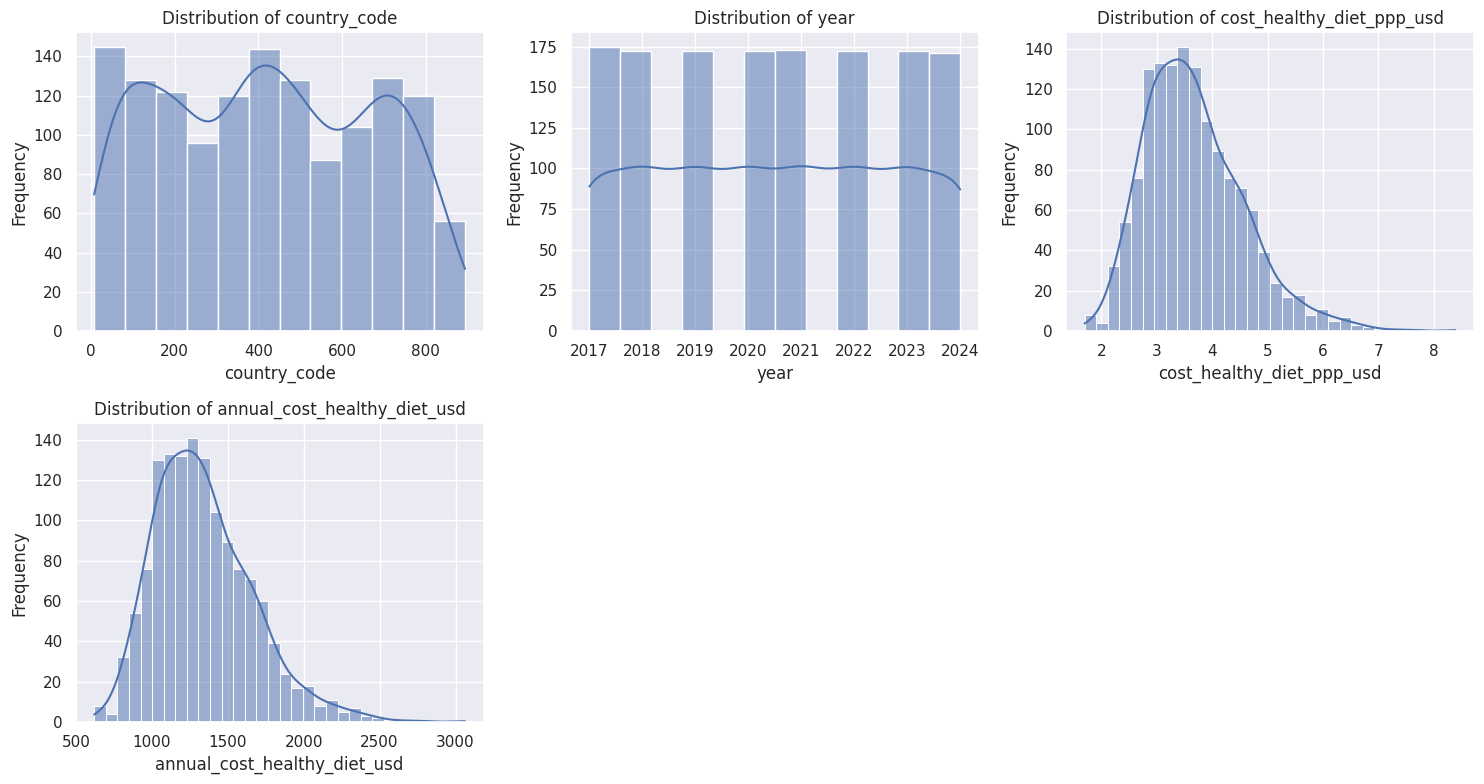

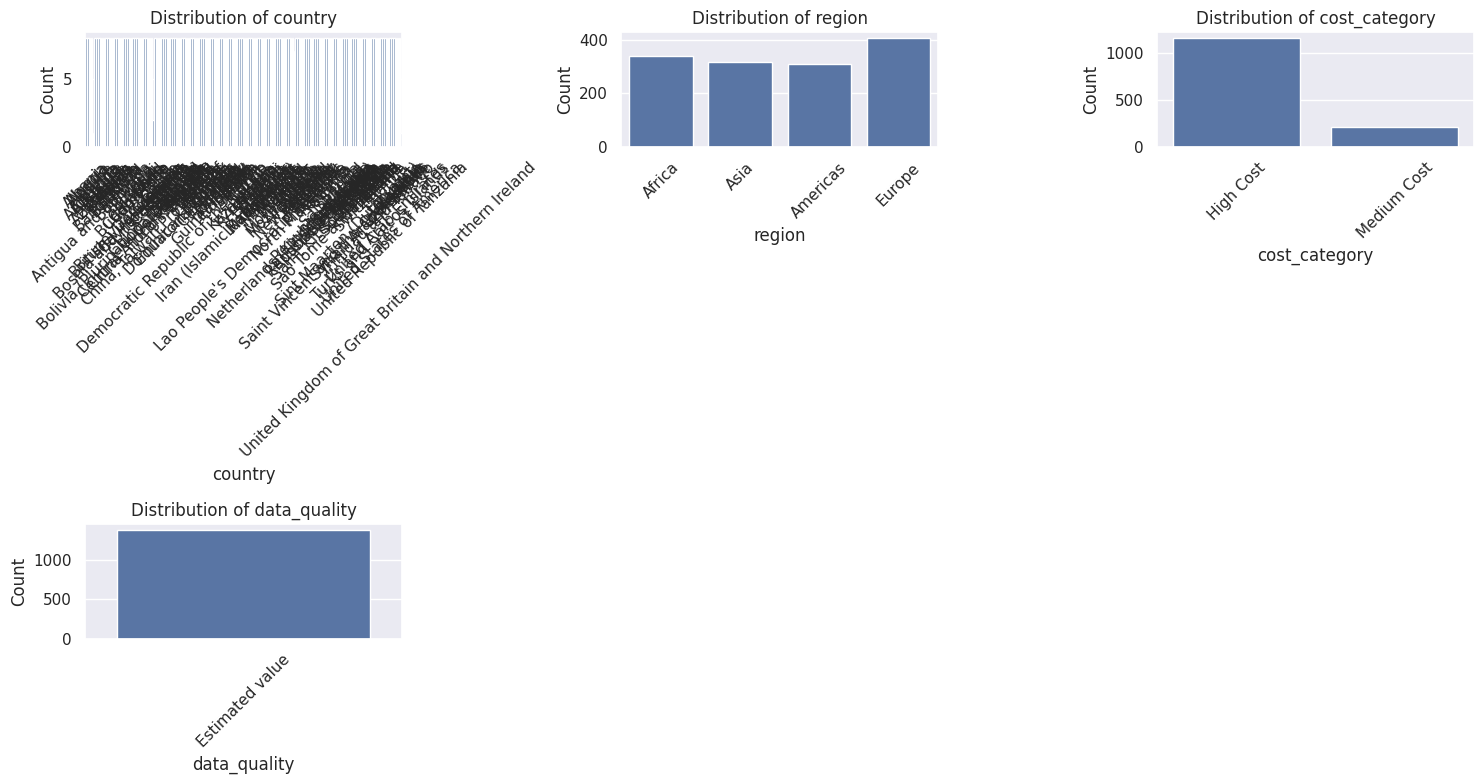

--- Categorical Value Counts ---

Value counts for country:
country
Albania                      8
Algeria                      8
Angola                       8
Antigua and Barbuda          8
Armenia                      8
                            ..
Uruguay                      8
Nicaragua                    7
China, Taiwan Province of    2
Argentina                    1
Zimbabwe                     1
Name: count, Length: 175, dtype: int64

Value counts for region:
region
Europe      409
Africa      339
Asia        319
Americas    312
Name: count, dtype: int64

Value counts for cost_category:
cost_category
High Cost      1160
Medium Cost     208
Name: count, dtype: int64

Value counts for data_quality:
data_quality
Estimated value    1379
Name: count, dtype: int64


In [ ]:
import math
# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

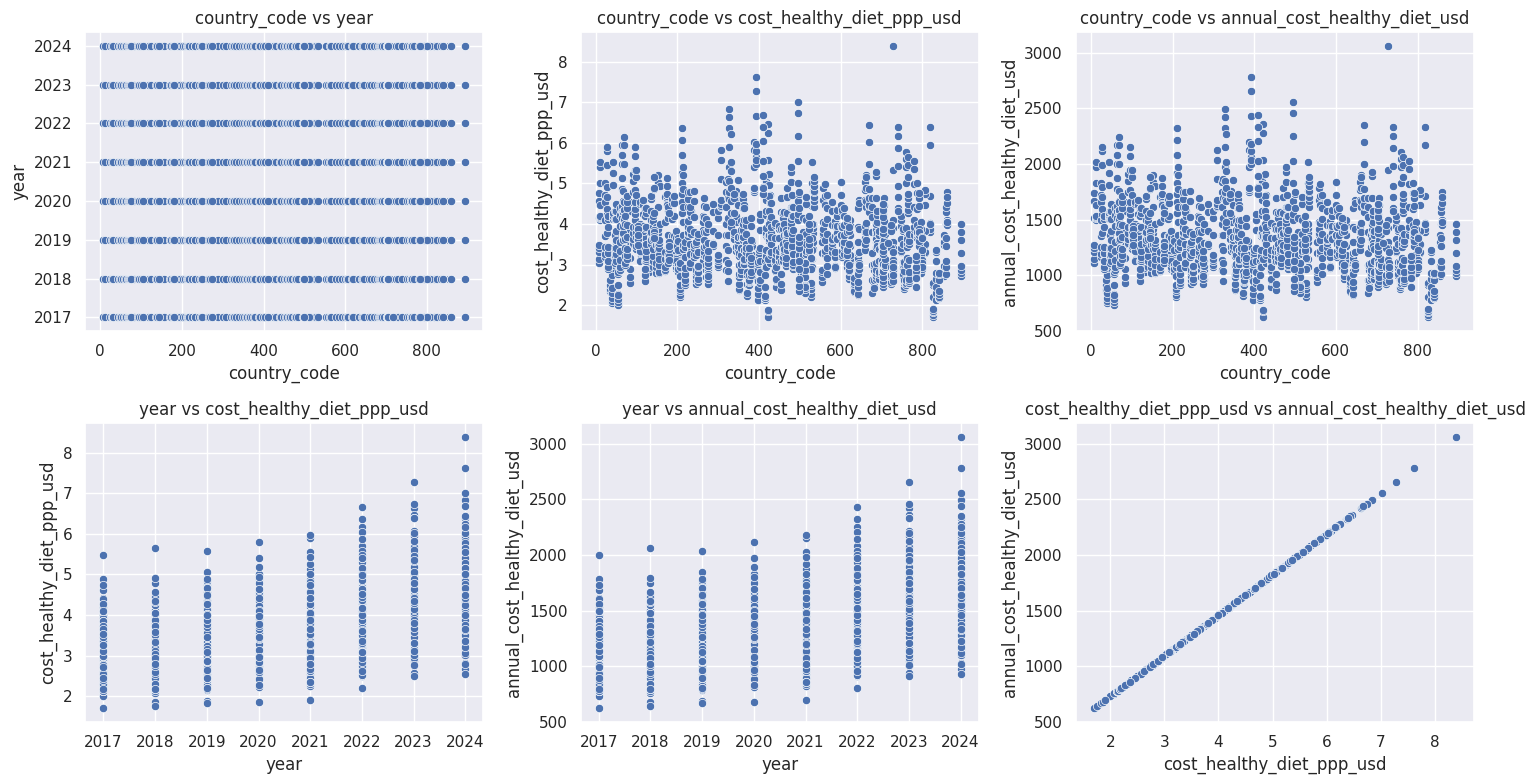

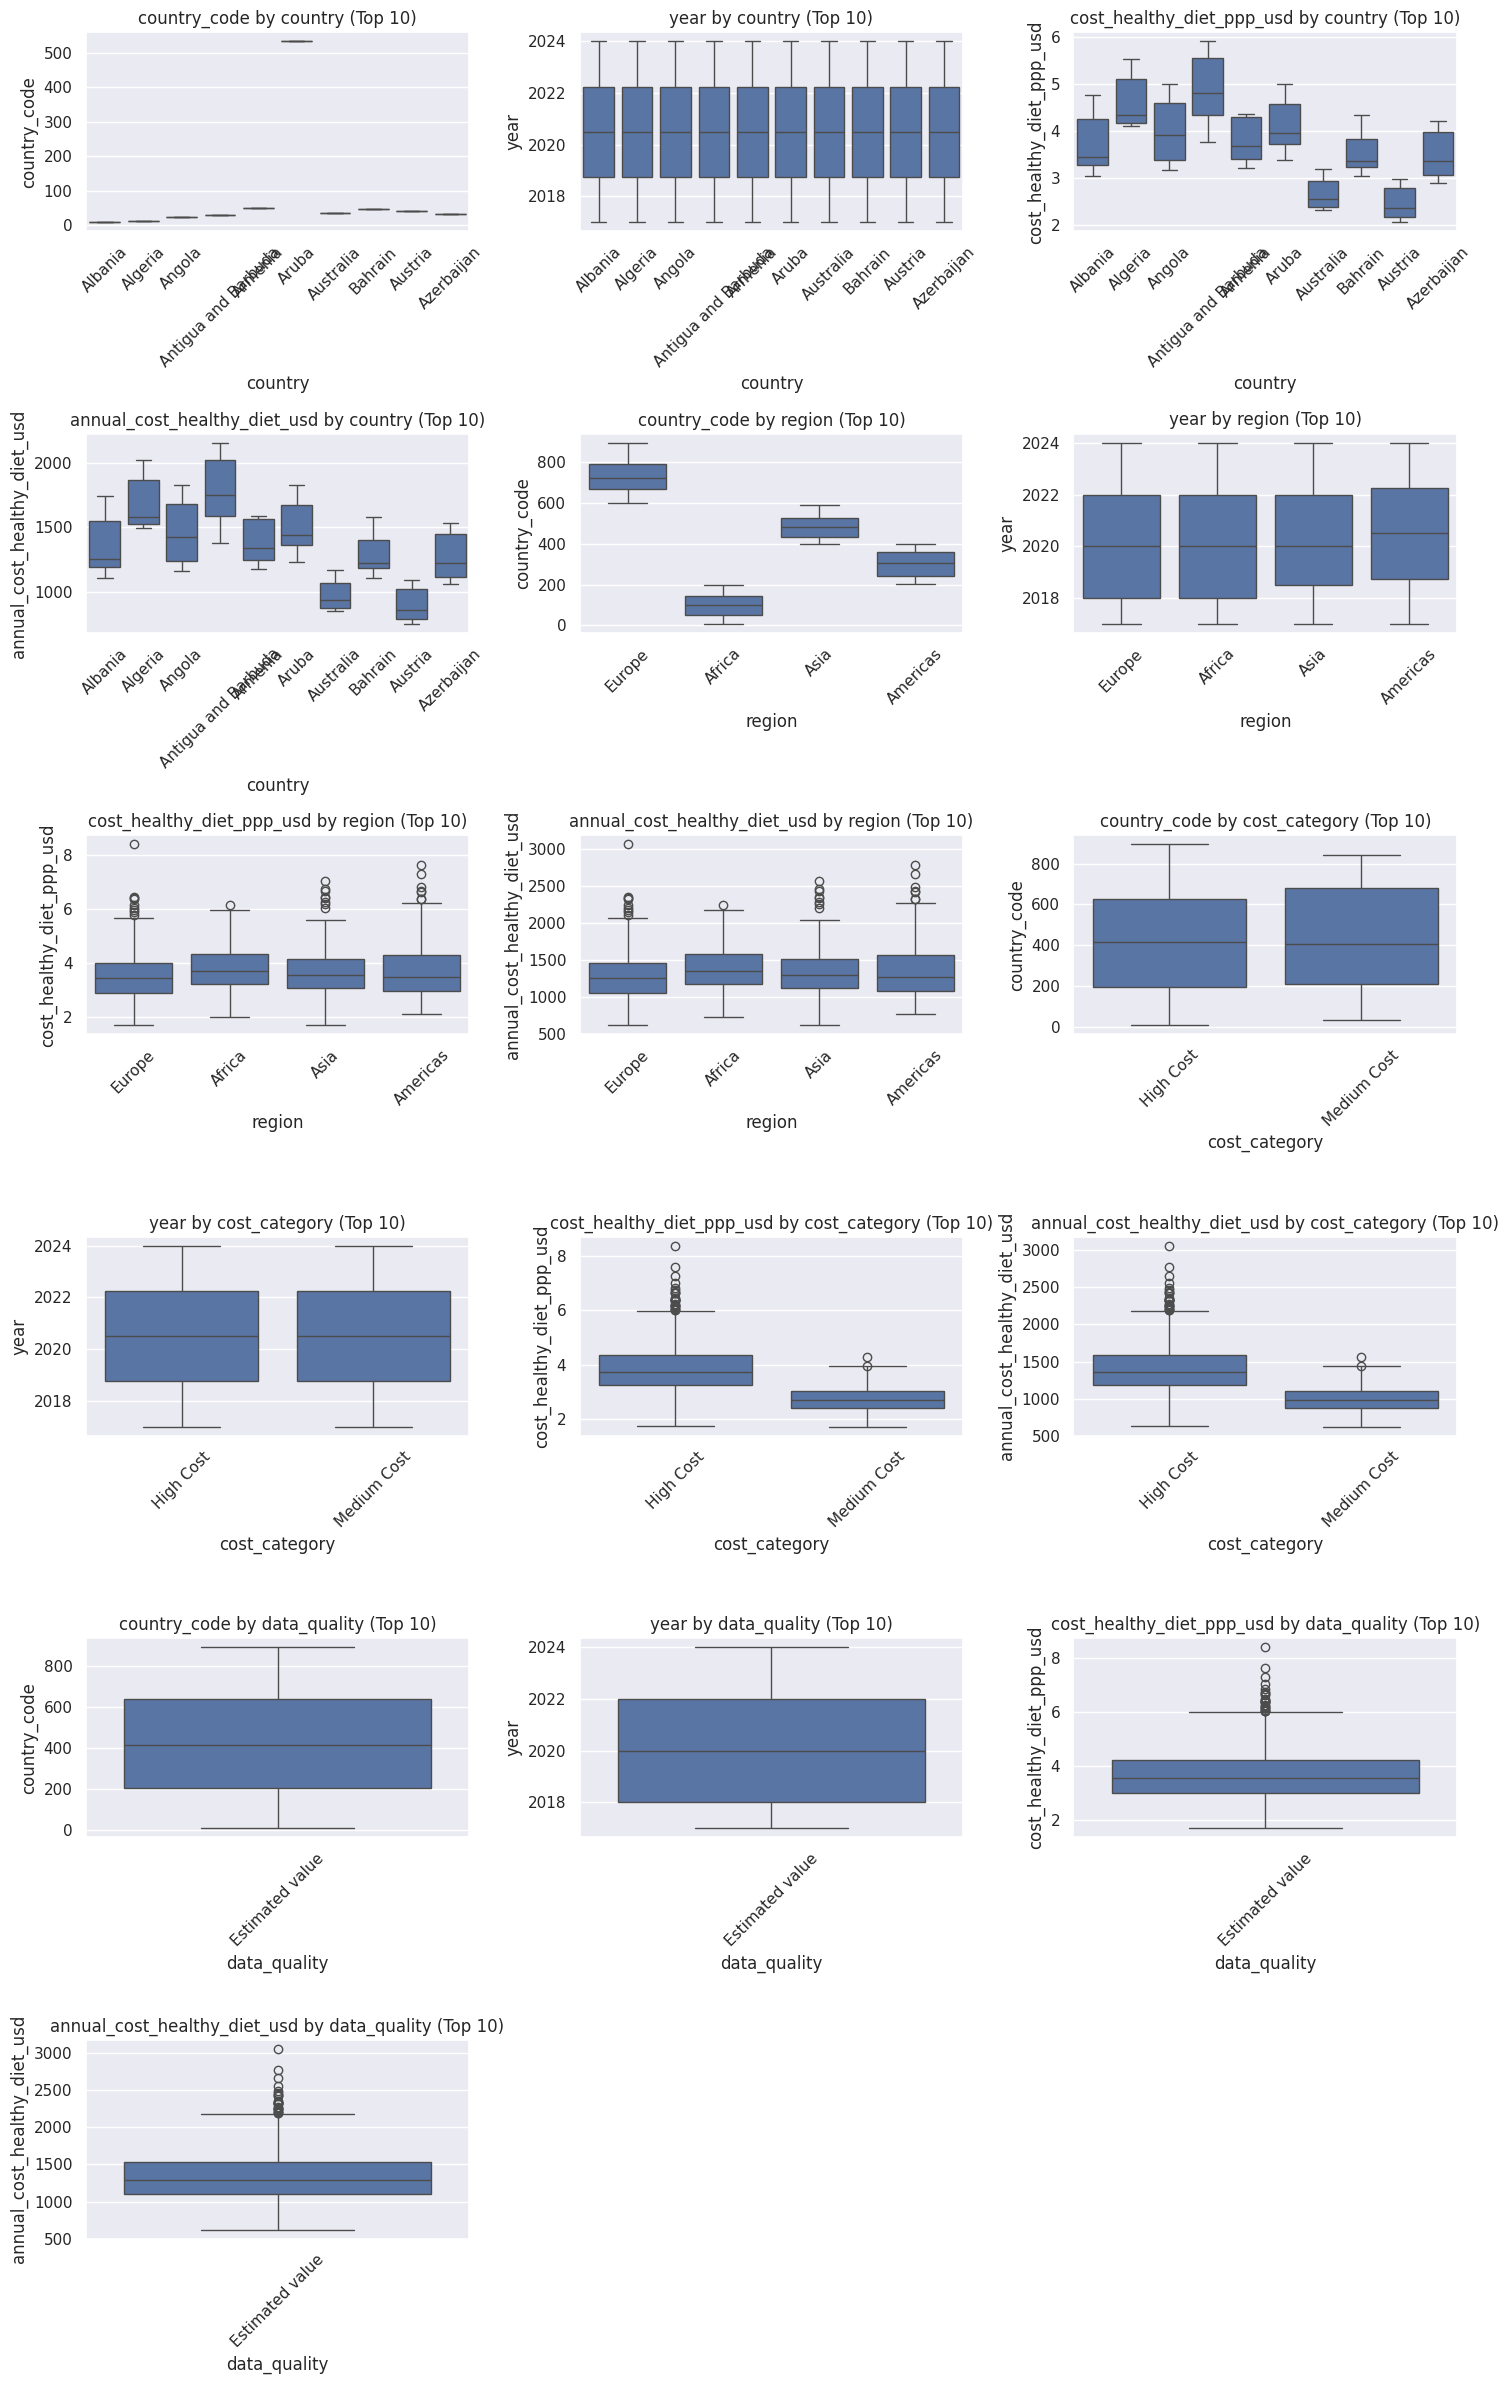

# Pairplot

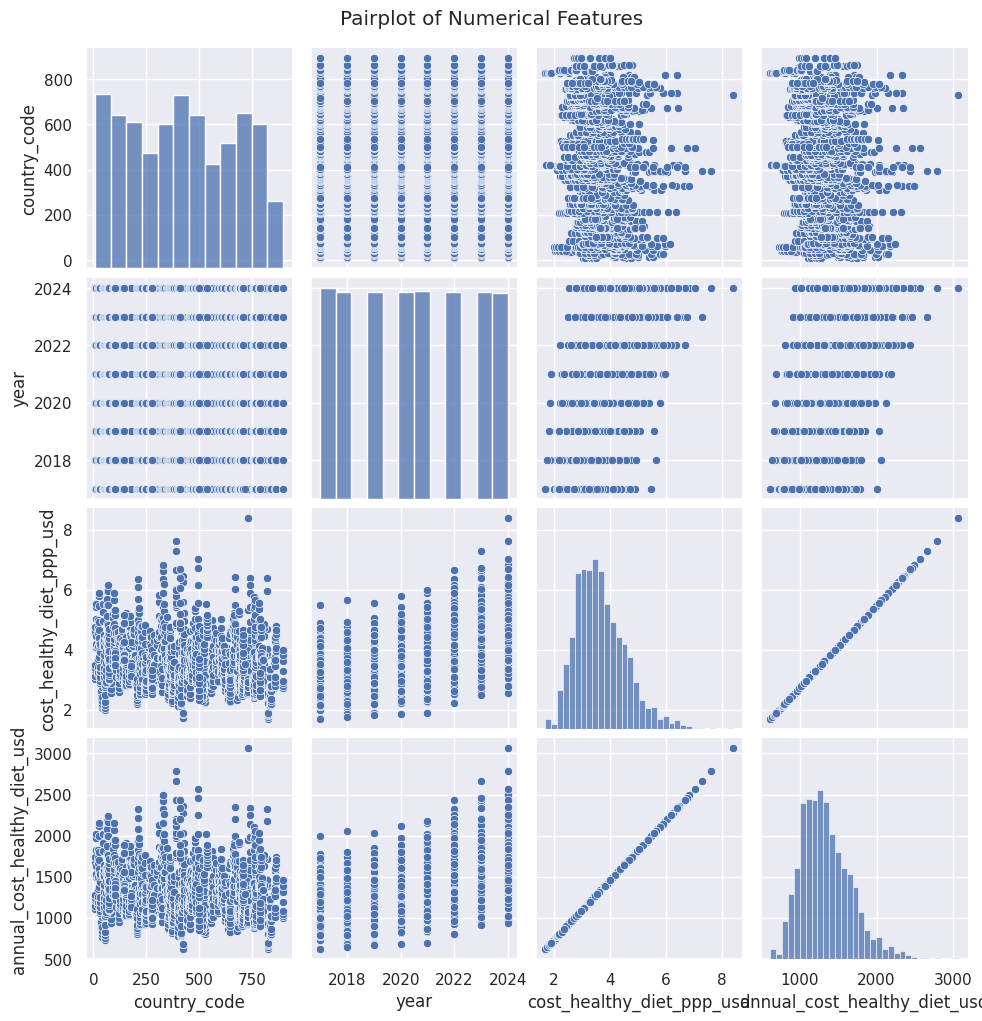

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

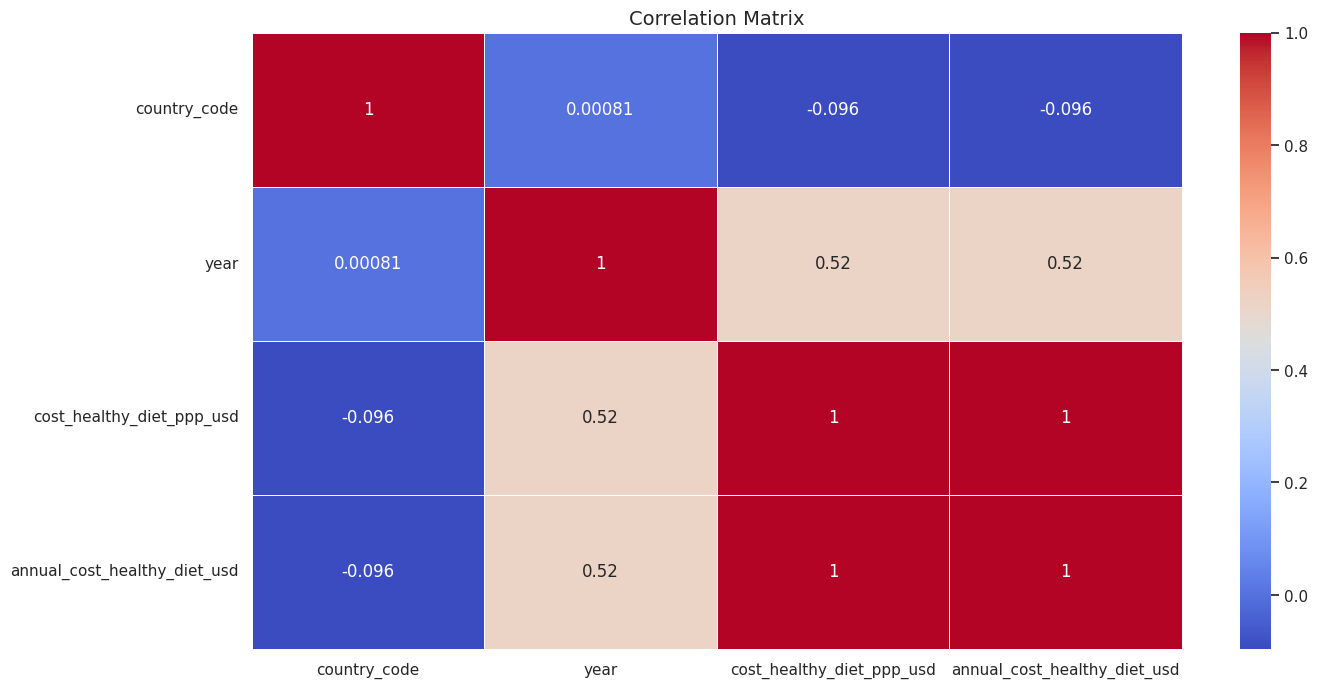

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. CALCULATING 'DIET INFLATION' (YoY Growth) ---
Tracking Inflation for: cost_healthy_diet_ppp_usd

Global Diet Cost Trend:
   year  cost_healthy_diet_ppp_usd  Inflation_Rate
0  2017                   3.140400             NaN
1  2018                   3.191860        1.638660
2  2019                   3.295058        3.233151
3  2020                   3.427791        4.028231
4  2021                   3.601561        5.069446
5  2022                   4.009884       11.337391
6  2023                   4.304128        7.337973
7  2024                   4.462982        3.690749


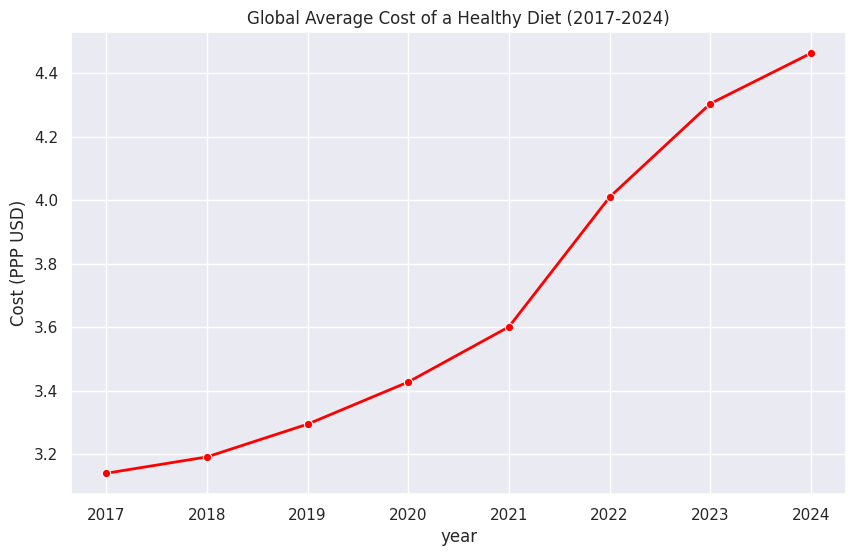


--- 2. STATISTICAL PROOF: IS 2024 REALLY MORE EXPENSIVE? (T-TEST) ---
Avg Cost 2017: $3.14
Avg Cost 2024: $4.46
P-Value: 1.2980e-37
✅ RESULT: Statistically Significant Increase! This is real inflation, not noise.

--- 3. REGIONAL INEQUALITY (ANOVA TEST) ---

Analyzing Inequality by: region


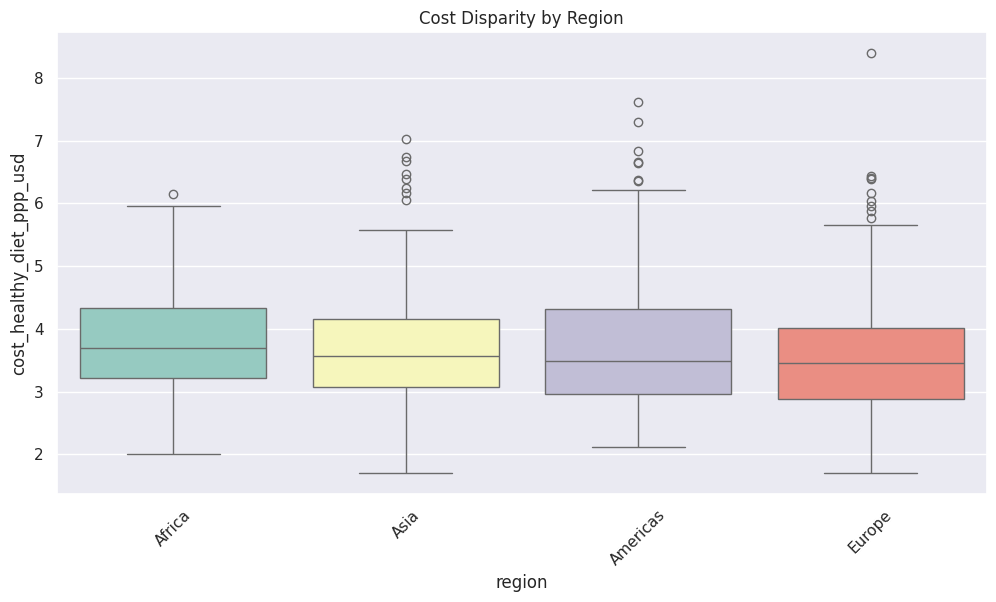

ANOVA P-Value: 2.8383e-03
✅ RESULT: Location Matters! Significant inequality exists between regions.


In [ ]:
from scipy import stats

print("--- 1. CALCULATING 'DIET INFLATION' (YoY Growth) ---")
# We need to track how prices change per country over time.
# Ensure 'year' is numeric
# Identify the 'Cost' column (adjust name if needed!)
cost_col = [c for c in df.columns if 'cost' in c.lower() and ('total' in c.lower() or 'healthy' in c.lower())][0]
print(f"Tracking Inflation for: {cost_col}")

# Grouping by year to see global trends
global_trend = df.groupby('year')[cost_col].mean().reset_index()

# 1. year-over-year Growth Rate (Global "Diet Inflation")
global_trend['Inflation_Rate'] = global_trend[cost_col].pct_change() * 100

print("\nGlobal Diet Cost Trend:")
print(global_trend)

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y=cost_col, data=global_trend, marker='o', color='red', linewidth=2)
plt.title(f'Global Average Cost of a Healthy Diet (2017-2024)')
plt.ylabel('Cost (PPP USD)')
plt.grid(True)
plt.show()


print("\n--- 2. STATISTICAL PROOF: IS 2024 REALLY MORE EXPENSIVE? (T-TEST) ---")
# Hypothesis: The cost in 2024 is significantly higher than in 2017.
# We compare the distribution of costs for all countries in 2017 vs 2024.

cost_2017 = df[df['year'] == 2017][cost_col]
cost_2024 = df[df['year'] == 2024][cost_col] # Or 2022/2023 if 2024 is partial

# T-Test
t_stat, p_val = stats.ttest_ind(cost_2024, cost_2017, equal_var=False)

print(f"Avg Cost 2017: ${cost_2017.mean():.2f}")
print(f"Avg Cost 2024: ${cost_2024.mean():.2f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("✅ RESULT: Statistically Significant Increase! This is real inflation, not noise.")
else:
    print("❌ RESULT: No significant difference. Prices are stable.")


print("\n--- 3. REGIONAL INEQUALITY (ANOVA TEST) ---")
# Do costs differ significantly by Continent/Region?
# Assuming you have a 'Continent' or 'Region' column.
region_col = [c for c in df.columns if 'region' in c.lower() or 'continent' in c.lower()]

if region_col:
    region_col = region_col[0]
    print(f"\nAnalyzing Inequality by: {region_col}")

    # Visualizing
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=region_col, y=cost_col, data=df, palette='Set3')
    plt.title('Cost Disparity by Region')
    plt.xticks(rotation=45)
    plt.show()

    # ANOVA Test
    groups = [df[df[region_col] == r][cost_col] for r in df[region_col].unique()]
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"ANOVA P-Value: {p_val:.4e}")
    if p_val < 0.05:
        print("✅ RESULT: Location Matters! Significant inequality exists between regions.")
else:
    print("⚠️ Region column not found. Skipping Inequality Analysis.")

# Time Series Analysis

--- 1. PREPARING THE TIME SERIES ---
Global Cost History:
year
2017    3.140400
2018    3.191860
2019    3.295058
2020    3.427791
2021    3.601561
2022    4.009884
2023    4.304128
2024    4.462982
Name: cost_healthy_diet_ppp_usd, dtype: float64

--- 2. STATIONARITY TEST (ADF TEST) ---
ADF P-Value: 0.9987
✅ Result: Data is Non-Stationary (It has a Trend).
   -> We must use a model that handles Trend (like Holt's Method).

--- 3. FORECASTING THE FUTURE (HOLT'S LINEAR TREND) ---

🔮 Price Forecast:
   2025: $4.62
   2026: $4.78

--- 4. VISUALIZING THE TRAJECTORY ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


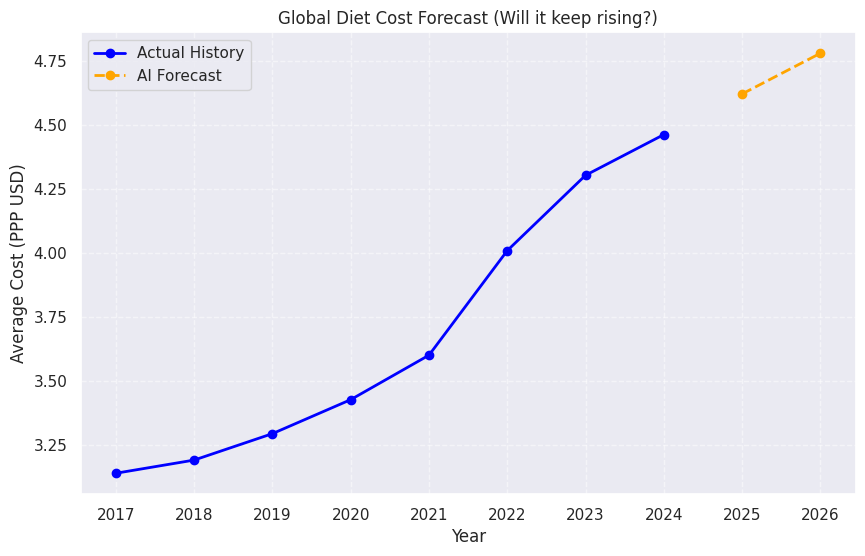


--- 5. WHO IS SUFFERING THE MOST? (CAGR ANALYSIS) ---

Top 10 Countries by CAGR (Highest Inflation):
country
China, Taiwan Province of    0.237500
Lebanon                      0.203405
South Sudan                  0.151261
Syrian Arab Republic         0.126914
Sao Tome and Principe        0.104771
Guinea                       0.101637
Malawi                       0.100070
Curaçao                      0.094204
Belize                       0.085288
Guatemala                    0.082920
Name: cost_healthy_diet_ppp_usd, dtype: float64

Bottom 10 Countries by CAGR (Lowest/Negative Inflation):
country
Democratic Republic of the Congo   -0.029602
Myanmar                            -0.002833
Panama                              0.005037
Comoros                             0.015668
Uzbekistan                          0.018416
Qatar                               0.019729
Kyrgyzstan                          0.021943
Sint Maarten (Dutch part)           0.022313
Uganda                              

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import Holt

print("--- 1. PREPARING THE TIME SERIES ---")
cost_col = [c for c in df.columns if 'cost' in c.lower() and ('total' in c.lower() or 'healthy' in c.lower())][0]

# Aggregate to get one global number per year
ts_data = df.groupby('year')[cost_col].mean()
print("Global Cost History:")
print(ts_data)


print("\n--- 2. STATIONARITY TEST (ADF TEST) ---")
# Theory: Time Series forecasting works best on "Stationary" data (stable mean).
# Real-world prices are usually "Non-Stationary" (they trend up). We verify this.

result = adfuller(ts_data)
p_value = result[1]

print(f"ADF P-Value: {p_value:.4f}")
if p_value > 0.05:
    print("✅ Result: Data is Non-Stationary (It has a Trend).")
    print("   -> We must use a model that handles Trend (like Holt's Method).")
else:
    print("❌ Result: Data is Stationary (Flat). Simple average would suffice.")


print("\n--- 3. FORECASTING THE FUTURE (HOLT'S LINEAR TREND) ---")
# fitting the model (Holt handles the trend automatically)
model = Holt(ts_data, initialization_method="estimated").fit(optimized=True)

# Predicting future
future_years = [ts_data.index.max() + 1, ts_data.index.max() + 2] # e.g., 2025, 2026
forecast = model.forecast(steps=2)

forecast_df = pd.DataFrame({'year': future_years, 'Forecast': forecast})

print("\n🔮 Price Forecast:")
for yr, val in zip(future_years, forecast):
    print(f"   {yr}: ${val:.2f}")


print("\n--- 4. VISUALIZING THE TRAJECTORY ---")
plt.figure(figsize=(10, 6))

# Plotting History
plt.plot(ts_data.index, ts_data.values, marker='o', label='Actual History', color='blue', linewidth=2)

# Plotting Forecast
plt.plot(forecast_df['year'], forecast_df['Forecast'], marker='o', label='AI Forecast', color='orange', linestyle='--', linewidth=2)

plt.title(f'Global Diet Cost Forecast (Will it keep rising?)')
plt.xlabel('Year')
plt.ylabel('Average Cost (PPP USD)')
plt.xticks(list(ts_data.index) + future_years)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


print("\n--- 5. WHO IS SUFFERING THE MOST? (CAGR ANALYSIS) ---")
# Compound Annual Growth Rate (CAGR) per country

def calculate_cagr(x):
    start_val = x.iloc[0]
    end_val = x.iloc[-1]
    num_years = len(x) - 1
    if start_val == 0: return 0
    return ((end_val / start_val) ** (1/num_years)) - 1

# Grouping by country and calculate CAGR
if 'country' in df.columns:
    country_col = 'country'

    # Filtering for countries with data in both 2017 and 2024
    valid_countries = df.groupby(country_col)['year'].nunique()
    valid_countries = valid_countries[valid_countries >= 2].index

    cagr_df = df[df[country_col].isin(valid_countries)].groupby(country_col)[cost_col].apply(calculate_cagr)
    print("\nTop 10 Countries by CAGR (Highest Inflation):")
    print(cagr_df.nlargest(10))

    print("\nBottom 10 Countries by CAGR (Lowest/Negative Inflation):")
    print(cagr_df.nsmallest(10))
else:
    print("⚠️ Country column not found. Skipping CAGR Analysis.")

# Feature Engineering (Economical Indicators)

--- 1. PREPARING THE DATASET ---
Target Variable: cost_healthy_diet_ppp_usd

--- 2. TIME MACHINE FEATURES (LAGS & ROLLING) ---
✅ Created: Cost_Last_Year, Inflation_Velocity, Rolling_Avg_3Y, Volatility_3Y

--- 3. ECONOMIC TIERS (K-MEANS CLUSTERING) ---
✅ Created: Cost_Tier (Clustered Countries by Expense)


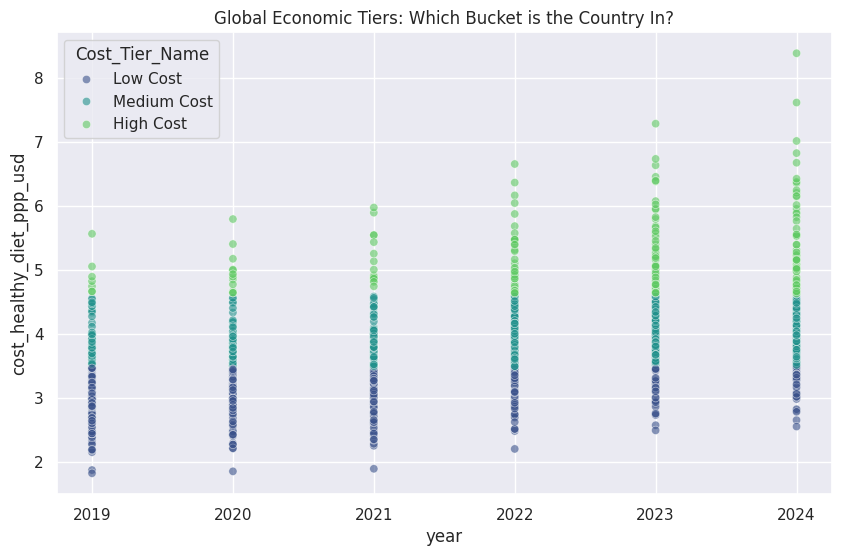


--- 4. FINAL ENCODING FOR ML ---
✅ One-Hot Encoded: region

Final ML Dataset Shape: (1026, 10)
   country_code  year  cost_healthy_diet_ppp_usd  \
2             8  2019                       3.32   
3             8  2020                       3.40   
4             8  2021                       3.49   
5             8  2022                       4.14   
6             8  2023                       4.58   

   annual_cost_healthy_diet_usd  Cost_Last_Year  Inflation_Velocity  \
2                       1211.80            3.13                0.19   
3                       1241.00            3.32                0.08   
4                       1273.85            3.40                0.09   
5                       1511.10            3.49                0.65   
6                       1671.70            4.14                0.44   

   Rolling_Avg_3Y  Volatility_3Y  Cost_Tier  Cost_Tier_Code  
2        3.163333       0.142945          0               1  
3        3.283333       0.138684        

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

print("--- 1. PREPARING THE DATASET ---")
# Re-identify the cost column
cost_col = [c for c in df.columns if 'cost' in c.lower() and ('total' in c.lower() or 'healthy' in c.lower())][0]
print(f"Target Variable: {cost_col}")

# Sort by Country and Year to ensure time calculations are correct
df = df.sort_values(by=['country', 'year']) # Corrected 'Country' to 'country' and 'Year' to 'year'

print("\n--- 2. TIME MACHINE FEATURES (LAGS & ROLLING) ---")
# Feature 1: Cost Last Year (Momentum)
df['Cost_Last_Year'] = df.groupby('country')[cost_col].shift(1) # Corrected 'Country' to 'country'

# Feature 2: Inflation Velocity (Change from last year)
df['Inflation_Velocity'] = df[cost_col] - df['Cost_Last_Year']

# Feature 3: 3-Year Stability (Rolling Mean)
df['Rolling_Avg_3Y'] = df.groupby('country')[cost_col].transform(lambda x: x.rolling(window=3).mean()) # Corrected 'Country' to 'country'

# Feature 4: Volatility Risk (Rolling Std Dev)
# High volatility = Unstable market
df['Volatility_3Y'] = df.groupby('country')[cost_col].transform(lambda x: x.rolling(window=3).std()) # Corrected 'Country' to 'country'

# Drop NaNs generated by shifting (First year of data has no history)
df_eng = df.dropna()
print("✅ Created: Cost_Last_Year, Inflation_Velocity, Rolling_Avg_3Y, Volatility_3Y")


print("\n--- 3. ECONOMIC TIERS (K-MEANS CLUSTERING) ---")
# Instead of just "Country Name", let's group them by "Cost Tier".
# Are they an "Expensive Nation", "Moderate Nation", or "Cheap Nation"?

# Reshape for Clustering
X_cluster = df_eng[[cost_col]].values

# Use K-Means to find 3 distinct groups
kmeans = KMeans(n_clusters=3, random_state=42)
df_eng['Cost_Tier'] = kmeans.fit_predict(X_cluster)

# Map clusters to human names (0,1,2 -> Low, Mid, High) based on average cost
cluster_map = df_eng.groupby('Cost_Tier')[cost_col].mean().sort_values()
tier_names = {cluster_map.index[0]: 'Low Cost', cluster_map.index[1]: 'Medium Cost', cluster_map.index[2]: 'High Cost'}
df_eng['Cost_Tier_Name'] = df_eng['Cost_Tier'].map(tier_names)

print("✅ Created: Cost_Tier (Clustered Countries by Expense)")

# Visualize the Tiers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y=cost_col, hue='Cost_Tier_Name', data=df_eng, palette='viridis', alpha=0.6) # Corrected 'Year' to 'year'
plt.title('Global Economic Tiers: Which Bucket is the Country In?')
plt.show()


print("\n--- 4. FINAL ENCODING FOR ML ---")
# Convert Text (Region/Country) to Numbers

# One-Hot Encoding for Region (if exists)
region_col = [c for c in df.columns if 'region' in c.lower() or 'continent' in c.lower()]
if region_col:
    df_ml = pd.get_dummies(df_eng, columns=[region_col[0]], drop_first=True)
    print(f"✅ One-Hot Encoded: {region_col[0]}")
else:
    df_ml = df_eng.copy()

# Label Encoding for Cost_Tier_Name (if we want to use it as a feature)
le = LabelEncoder()
df_ml['Cost_Tier_Code'] = le.fit_transform(df_ml['Cost_Tier_Name'])

# Select Final Columns for Machine Learning
# We remove 'Country' (Text) and keep the mathematical features
numeric_cols = df_ml.select_dtypes(include=np.number).columns
df_ml = df_ml[numeric_cols]

print(f"\nFinal ML Dataset Shape: {df_ml.shape}")
print(df_ml.head())

# Machine Learning

--- 1. SETTING THE EXAM (TRAIN/TEST SPLIT) ---
Training on years: 2019 - 2022
Testing on years: 2023 - 2024
Training Samples: 684
Testing Samples: 342

--- 2. TRAINING THE AI ECONOMIST ---
✅ Model Trained.

--- 3. EVALUATING PERFORMANCE ---
💰 Average Error: $0.03
   (On average, the AI is off by this amount per day.)
🎯 Accuracy (R2 Score): 97.3%


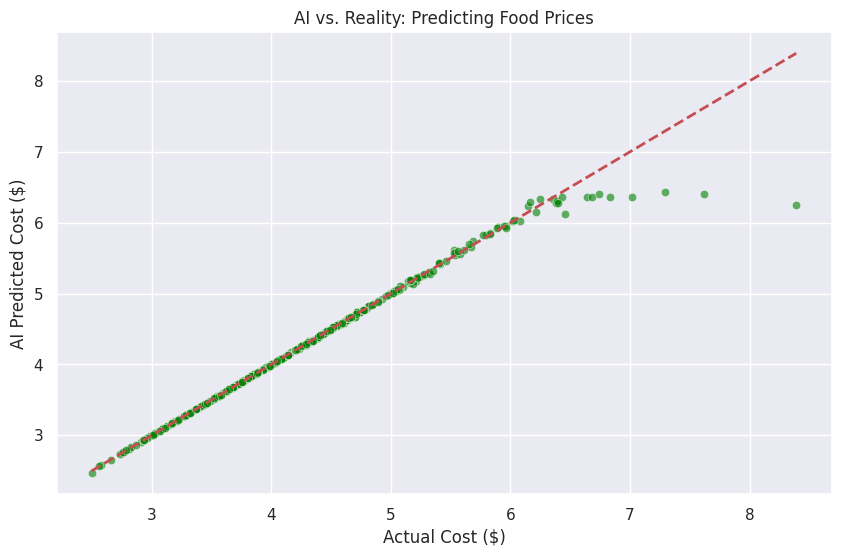


--- 4. THE DRIVERS OF INFLATION (FEATURE IMPORTANCE) ---


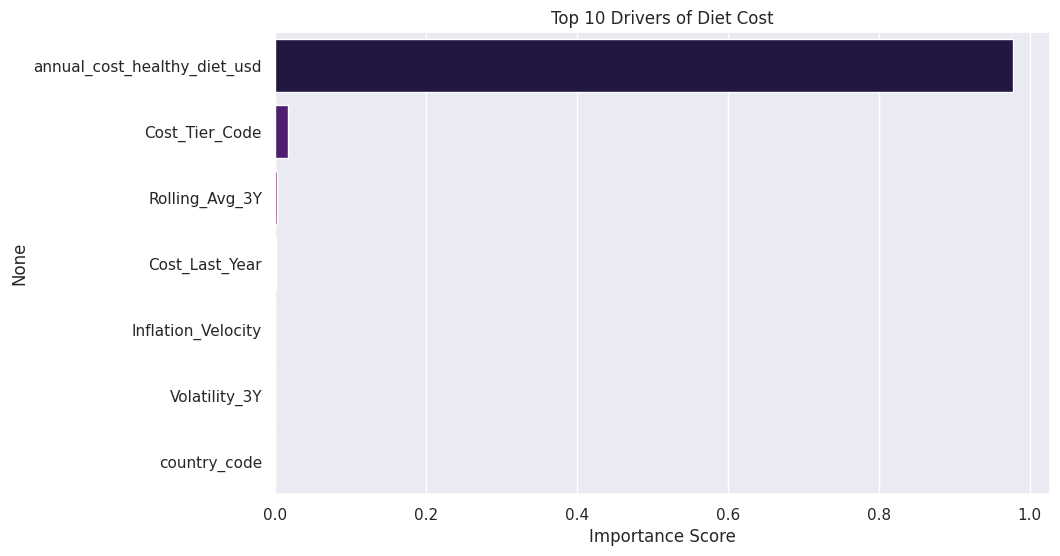

In [ ]:
# ==========================================
# PHASE 5: MACHINE LEARNING (THE PREDICTION)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("--- 1. SETTING THE EXAM (TRAIN/TEST SPLIT) ---")

# Predicting the Cost
target = cost_col
features = [c for c in df_ml.columns if c not in [target, 'country', 'year', 'Cost_Tier', 'Cost_Tier_Name']]

X = df_ml[features]
y = df_ml[target]

# Split Data (80% Training, 20% Testing)
# We should ideally split by year (Train on 2017-2022, Test on 2023-2024)
split_year = 2022
X_train = X[df_ml['year'] <= split_year]
y_train = y[df_ml['year'] <= split_year]
X_test = X[df_ml['year'] > split_year]
y_test = y[df_ml['year'] > split_year]

print(f"Training on years: {df_ml['year'].min()} - {split_year}")
print(f"Testing on years: {split_year + 1} - {df_ml['year'].max()}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")


print("\n--- 2. TRAINING THE AI ECONOMIST ---")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model Trained.")


print("\n--- 3. EVALUATING PERFORMANCE ---")
# Predicting
preds = model.predict(X_test)

# Evaluataing
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"💰 Average Error: ${mae:.2f}")
print("   (On average, the AI is off by this amount per day.)")
print(f"🎯 Accuracy (R2 Score): {r2*100:.1f}%")

# Visualizing Success
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=preds, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Cost ($)')
plt.ylabel('AI Predicted Cost ($)')
plt.title('AI vs. Reality: Predicting Food Prices')
plt.show()


print("\n--- 4. THE DRIVERS OF INFLATION (FEATURE IMPORTANCE) ---")

# What drives the cost?
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Top 10 Drivers of Diet Cost')
plt.xlabel('Importance Score')
plt.show()

# Thank You